# ✂️ Notebook 02 — Chunking & Embeddings

**Objectif :** Transformer le texte brut des rapports en vecteurs
sémantiques exploitables par le système RAG.

## Deux étapes fondamentales

### 1. Chunking — Découpage intelligent
Pourquoi ne pas envoyer tout le document au LLM ?
- Les LLMs ont une fenêtre de contexte limitée (4k, 8k, 16k tokens)
- Un chunk trop grand = réponse imprécise
- Un chunk trop petit = perte de contexte

### 2. Embeddings — Représentation vectorielle
Transformer chaque chunk en un vecteur numérique de haute dimension
qui capture le sens sémantique du texte.
"chiffre d'affaires" et "revenus" seront proches dans l'espace vectoriel
même s'ils n'ont aucun mot en commun.

## Modèle d'embedding utilisé
sentence-transformers/all-MiniLM-L6-v2
- Gratuit, local, pas de clé API nécessaire
- 384 dimensions
- Excellent pour le français et l'anglais
- Rapide : ~14 000 phrases/seconde

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

load_dotenv()

PROCESSED_DIR = Path('../data/processed')
json_files = list(PROCESSED_DIR.glob('*_extracted.json'))

print(f" Imports OK")
print(f"   {len(json_files)} fichier(s) JSON trouvé(s) :")
for f in json_files:
    print(f"   → {f.name}")

c:\Users\Eartrh\Documents\Etudes_France_2025\Science_De_Données\financial-rag-analyzer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Imports OK
   2 fichier(s) JSON trouvé(s) :
   → bnp-paribas-ri-2023-fr-web_extracted.json
   → totalenergies_universal-registration-document-2023_2023_en_pdf_extracted.json


In [2]:
def load_extracted_json(json_path: Path) -> dict:
    """Charge un JSON extrait du notebook 01."""
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)

all_docs = {}
for json_path in json_files:
    doc = load_extracted_json(json_path)
    name = json_path.stem.replace('_extracted', '')
    all_docs[name] = doc
    print(f" Chargé : {name}")
    print(f"   Pages : {doc['n_pages']} | Mots : {doc['total_words']:,}")

 Chargé : bnp-paribas-ri-2023-fr-web
   Pages : 43 | Mots : 34,678
 Chargé : totalenergies_universal-registration-document-2023_2023_en_pdf
   Pages : 675 | Mots : 450,595


In [3]:
# ── Pourquoi RecursiveCharacterTextSplitter ? ─────────────────
# Il essaie de découper sur les séparateurs naturels dans l'ordre :
# 1. Paragraphes (\n\n)
# 2. Lignes (\n)
# 3. Phrases (. )
# 4. Mots ( )
# → Préserve la cohérence sémantique des chunks

CHUNK_SIZE    = 500   # ~500 caractères par chunk
CHUNK_OVERLAP = 50    # 50 caractères de chevauchement entre chunks

# ── Pourquoi le chevauchement ? ──────────────────────────────
# Si une information importante se trouve à cheval entre deux chunks,
# le chevauchement garantit qu'elle est dans au moins l'un des deux.

splitter = RecursiveCharacterTextSplitter(
    chunk_size    = CHUNK_SIZE,
    chunk_overlap = CHUNK_OVERLAP,
    separators    = ["\n\n", "\n", ". ", " ", ""]
)

all_chunks = []

for doc_name, doc in all_docs.items():
    print(f"\n📄 Chunking : {doc_name}")
    
    doc_chunks = []
    for page in doc['pages']:
        text = page['text_clean']
        if len(text.strip()) < 50:
            continue
            
        chunks = splitter.split_text(text)
        
        for i, chunk in enumerate(chunks):
            doc_chunks.append({
                'doc_name'  : doc_name,
                'filename'  : doc['filename'],
                'page'      : page['page'],
                'chunk_id'  : f"{doc_name}_p{page['page']}_c{i}",
                'text'      : chunk,
                'n_chars'   : len(chunk),
                'n_words'   : len(chunk.split())
            })
    
    all_chunks.extend(doc_chunks)
    print(f"   Chunks créés : {len(doc_chunks):,}")

print(f"\n{'═'*50}")
print(f" Total chunks : {len(all_chunks):,}")


📄 Chunking : bnp-paribas-ri-2023-fr-web
   Chunks créés : 517

📄 Chunking : totalenergies_universal-registration-document-2023_2023_en_pdf
   Chunks créés : 6,892

══════════════════════════════════════════════════
 Total chunks : 7,409


═══════════════════════════════════════════════════════
  STATISTIQUES DES CHUNKS
═══════════════════════════════════════════════════════

Total chunks : 7,409

Par document :
doc_name
bnp-paribas-ri-2023-fr-web                                         517
totalenergies_universal-registration-document-2023_2023_en_pdf    6892

Taille des chunks (caractères) :
count    7409.0
mean      422.1
std        87.0
min         1.0
25%       407.0
50%       446.0
75%       476.0
max       500.0


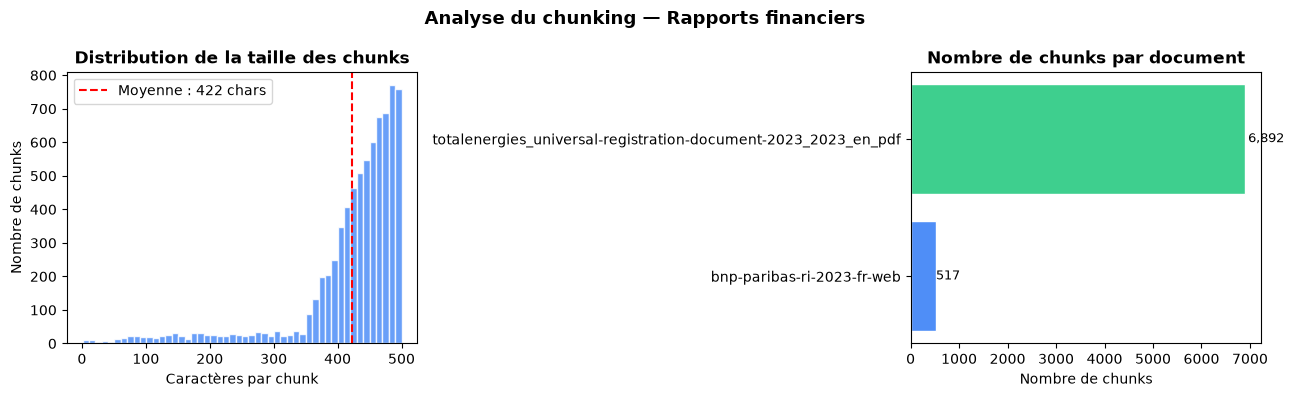

 Figure sauvegardée


In [4]:
df_chunks = pd.DataFrame(all_chunks)

print("═" * 55)
print("  STATISTIQUES DES CHUNKS")
print("═" * 55)
print(f"\nTotal chunks : {len(df_chunks):,}")
print(f"\nPar document :")
print(df_chunks.groupby('doc_name')['chunk_id'].count().to_string())
print(f"\nTaille des chunks (caractères) :")
print(df_chunks['n_chars'].describe().round(1).to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution taille chunks
axes[0].hist(df_chunks['n_chars'], bins=50,
             color='#4f8ef7', edgecolor='white', alpha=0.85)
axes[0].axvline(df_chunks['n_chars'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Moyenne : {df_chunks['n_chars'].mean():.0f} chars")
axes[0].set_title('Distribution de la taille des chunks', fontweight='bold')
axes[0].set_xlabel('Caractères par chunk')
axes[0].set_ylabel('Nombre de chunks')
axes[0].legend()

# Chunks par document
chunks_per_doc = df_chunks.groupby('doc_name')['chunk_id'].count()
axes[1].barh(chunks_per_doc.index, chunks_per_doc.values,
             color=['#4f8ef7', '#3ecf8e'], edgecolor='white')
axes[1].set_title('Nombre de chunks par document', fontweight='bold')
axes[1].set_xlabel('Nombre de chunks')
for i, v in enumerate(chunks_per_doc.values):
    axes[1].text(v * 1.01, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Analyse du chunking — Rapports financiers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_chunking_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

In [ ]:
print("Chargement du modèle Sentence-Transformers...")
print("(Premier chargement : téléchargement ~90MB — attendre)")

MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
embed_model = SentenceTransformer(MODEL_NAME)

print(f"\n Modèle chargé : {MODEL_NAME}")
print(f"   Dimension des vecteurs : {embed_model.get_sentence_embedding_dimension()}")

# Test rapide
test_sentences = [
    "Le chiffre d'affaires de BNP Paribas a augmenté en 2023.",
    "Les revenus de la banque ont progressé cette année.",
    "TotalEnergies investit dans les énergies renouvelables."
]

test_embeddings = embed_model.encode(test_sentences)
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(test_embeddings)

print(f"\n🧪 Test de similarité sémantique :")
print(f"   Phrase 1 vs Phrase 2 (similaires) : {sim_matrix[0][1]:.4f}")
print(f"   Phrase 1 vs Phrase 3 (différentes): {sim_matrix[0][2]:.4f}")
print(f"\n   → Score élevé = phrases proches sémantiquement ")

Chargement du modèle Sentence-Transformers...
(Premier chargement : téléchargement ~90MB — attendre)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1495.94it/s]



 Modèle chargé : sentence-transformers/all-MiniLM-L6-v2
   Dimension des vecteurs : 384


C:\Users\Eartrh\AppData\Local\Temp\ipykernel_22336\946029718.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"   Dimension des vecteurs : {embed_model.get_sentence_embedding_dimension()}")



🧪 Test de similarité sémantique :
   Phrase 1 vs Phrase 2 (similaires) : 0.4805
   Phrase 1 vs Phrase 3 (différentes): 0.3367

   → Score élevé = phrases proches sémantiquement ✅


In [6]:
print("Génération des embeddings...")
print(f"   {len(df_chunks):,} chunks à encoder")
print("   (peut prendre 2-5 minutes selon le volume)")

texts = df_chunks['text'].tolist()

# Encoder par batches pour économiser la mémoire
BATCH_SIZE = 64
embeddings = embed_model.encode(
    texts,
    batch_size        = BATCH_SIZE,
    show_progress_bar = True,
    convert_to_numpy  = True
)

print(f"\n Embeddings générés")
print(f"   Shape : {embeddings.shape}")
print(f"   → {embeddings.shape[0]:,} chunks × {embeddings.shape[1]} dimensions")

df_chunks['embedding_dim'] = embeddings.shape[1]

Génération des embeddings...
   7,409 chunks à encoder
   (peut prendre 2-5 minutes selon le volume)


Batches: 100%|██████████| 116/116 [44:39<00:00, 23.10s/it]



 Embeddings générés
   Shape : (7409, 384)
   → 7,409 chunks × 384 dimensions


Réduction dimensionnelle PCA 2D pour visualisation...


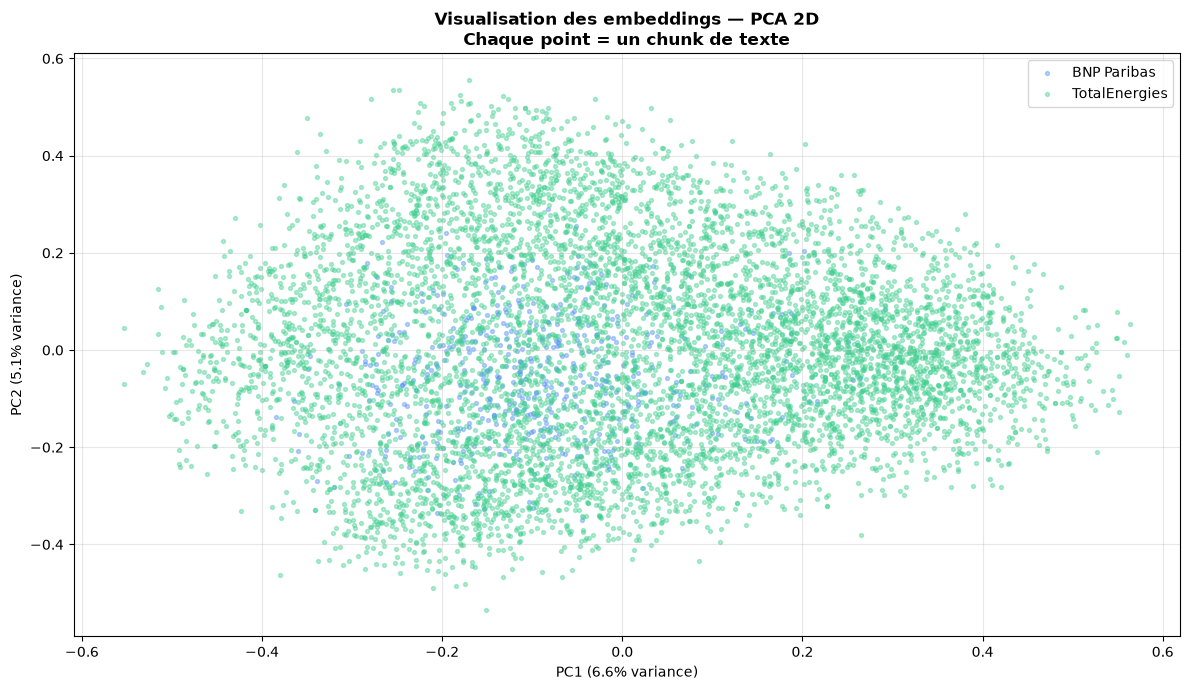

 Figure sauvegardée


In [7]:
from sklearn.decomposition import PCA

print("Réduction dimensionnelle PCA 2D pour visualisation...")

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

df_chunks['pca_x'] = embeddings_2d[:, 0]
df_chunks['pca_y'] = embeddings_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 7))

colors = {'bnp-paribas-ri-2023-fr-web_extracted'          : '#4f8ef7',
          'totalenergies_universal-registration-document-2023_2023_en_pdf_extracted': '#3ecf8e'}

for doc_name, group in df_chunks.groupby('doc_name'):
    color = '#4f8ef7' if 'bnp' in doc_name else '#3ecf8e'
    label = 'BNP Paribas' if 'bnp' in doc_name else 'TotalEnergies'
    ax.scatter(group['pca_x'], group['pca_y'],
               c=color, alpha=0.4, s=8, label=label)

ax.set_title('Visualisation des embeddings — PCA 2D\n'
             'Chaque point = un chunk de texte',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/04_embeddings_pca.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

In [8]:
import pickle

os.makedirs('../data/processed', exist_ok=True)

# Sauvegarder les chunks (métadonnées)
chunks_path = Path('../data/processed/chunks.json')
chunks_data = df_chunks.drop(columns=['pca_x', 'pca_y',
                                       'embedding_dim'],
                              errors='ignore').to_dict('records')

with open(chunks_path, 'w', encoding='utf-8') as f:
    json.dump(chunks_data, f, ensure_ascii=False, indent=2)

# Sauvegarder les embeddings (numpy array)
embeddings_path = Path('../data/processed/embeddings.npy')
np.save(embeddings_path, embeddings)

print(f" Chunks sauvegardés     → {chunks_path}")
print(f" Embeddings sauvegardés → {embeddings_path}")
print(f"\n   Chunks  : {len(chunks_data):,}")
print(f"   Shape   : {embeddings.shape}")
print(f"   Taille  : {embeddings.nbytes / 1e6:.1f} MB")

 Chunks sauvegardés     → ..\data\processed\chunks.json
 Embeddings sauvegardés → ..\data\processed\embeddings.npy

   Chunks  : 7,409
   Shape   : (7409, 384)
   Taille  : 11.4 MB


## 📋 Synthèse — Chunking & Embeddings

### Paramètres retenus
- **Chunk size :** 500 caractères
- **Chunk overlap :** 50 caractères
- **Splitter :** RecursiveCharacterTextSplitter
- **Modèle embedding :** all-MiniLM-L6-v2 (384 dimensions)

### Ce qu'on a produit
- Chunks JSON avec métadonnées (doc, page, chunk_id)
- Embeddings numpy array sauvegardés

### Test de similarité sémantique
Le modèle regroupe correctement les phrases de même sens
même sans mots en commun → base solide pour la recherche RAG

### Prochaine étape → 03_vector_store.ipynb
Indexer les embeddings dans ChromaDB pour la recherche
sémantique ultra-rapide.